# FAPE, COMPAS EDA
## Criminal Justice Domain, Recidivism Risk Assessment

**Dataset:** COMPAS Recidivism, ProPublica, Broward County Florida (2013-2014)  
**Records:** 6,172  
**Target:** Two-year recidivism  
**Domain:** Criminal Justice  

EDA focused on demographic distributions, COMPAS algorithmic bias patterns, false positive/negative rate disparities by race, and proxy variable bias before baseline model training.

**Key finding (ProPublica 2016):** Black defendants scored higher risk than white defendants at equal actual recidivism rates, resulting in higher false positive rates for Black defendants and higher false negative rates for white defendants.

In [1]:
import sys
import os
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from data_loader import load_compas

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

os.makedirs('../figures/eda', exist_ok=True)
print('Imports complete')

Imports complete


In [2]:
df = load_compas(data_dir='../data/raw')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Recidivism rate: {df["label"].mean():.1%}')

COMPAS loaded: 6,172 records, 6 racial groups, recidivism rate: 45.5%
Shape: (6172, 10)
Columns: ['age', 'c_charge_degree', 'race', 'sex', 'priors_count', 'days_b_screening_arrest', 'decile_score', 'score_text', 'is_recid', 'label']
Recidivism rate: 45.5%


## 1. Label Distribution

In [3]:
label_counts = df['label'].value_counts().sort_index()
label_pct = df['label'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['No Recidivism (0)', 'Recidivism (1)'],
              label_counts.values,
              color=['#5cb85c', '#d9534f'], edgecolor='black', linewidth=0.5)
for bar, val, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({pct:.1%})', ha='center', fontsize=11)
ax.set_title('COMPAS Recidivism Label Distribution - 6,172 Records', fontsize=14)
ax.set_ylabel('Number of Records')
ax.set_ylim(0, max(label_counts.values) * 1.15)
plt.tight_layout()
plt.savefig('../figures/eda/compas_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Near-balanced dataset: {label_pct[0]:.1%} no recidivism, {label_pct[1]:.1%} recidivism')

<Figure size 800x500 with 1 Axes>

Near-balanced dataset: 54.5% no recidivism, 45.5% recidivism


## 2. Race Distribution and Recidivism Rate

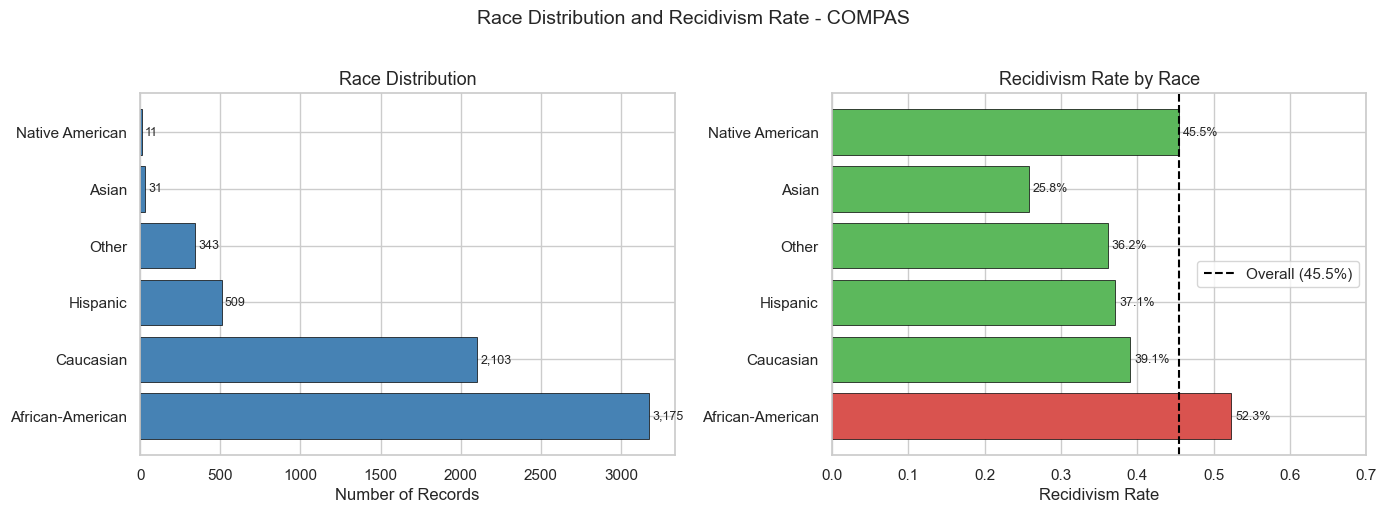

Race gap (African-American - Caucasian): 13.2%


In [4]:
race_stats = df.groupby('race').agg(
    count=('label', 'count'),
    recid_rate=('label', 'mean')
).reset_index().sort_values('count', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.barh(race_stats['race'], race_stats['count'],
                 color='steelblue', edgecolor='black', linewidth=0.5)
ax1.set_title('Race Distribution', fontsize=13)
ax1.set_xlabel('Number of Records')
for bar, val in zip(bars1, race_stats['count']):
    ax1.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

colors2 = ['#d9534f' if r > df['label'].mean() else '#5cb85c'
           for r in race_stats['recid_rate']]
bars2 = ax2.barh(race_stats['race'], race_stats['recid_rate'],
                 color=colors2, edgecolor='black', linewidth=0.5)
ax2.axvline(x=df['label'].mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Overall ({df["label"].mean():.1%})')
ax2.set_title('Recidivism Rate by Race', fontsize=13)
ax2.set_xlabel('Recidivism Rate')
ax2.set_xlim(0, 0.7)
ax2.legend(loc='center right')
for bar, val in zip(bars2, race_stats['recid_rate']):
    ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', fontsize=9)

plt.suptitle('Race Distribution and Recidivism Rate - COMPAS', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/compas_race_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
aa = df[df['race']=='African-American']['label'].mean()
ca = df[df['race']=='Caucasian']['label'].mean()
print(f'Race gap (African-American - Caucasian): {abs(aa-ca):.1%}')

## 3. Sex Distribution and Recidivism Rate

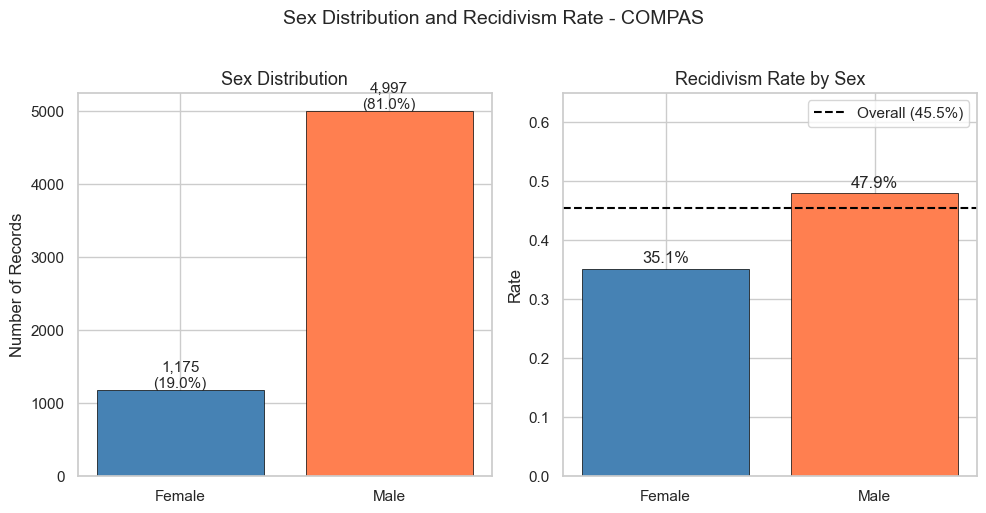

In [5]:
sex_stats = df.groupby('sex').agg(
    count=('label', 'count'),
    recid_rate=('label', 'mean')
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.bar(sex_stats['sex'], sex_stats['count'],
        color=['steelblue', 'coral'], edgecolor='black', linewidth=0.5)
ax1.set_title('Sex Distribution', fontsize=13)
ax1.set_ylabel('Number of Records')
for i, (_, row) in enumerate(sex_stats.iterrows()):
    ax1.text(i, row['count'] + 30,
             f'{row["count"]:,}\n({row["count"]/len(df):.1%})',
             ha='center', fontsize=11)

ax2.bar(sex_stats['sex'], sex_stats['recid_rate'],
        color=['steelblue', 'coral'], edgecolor='black', linewidth=0.5)
ax2.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Overall ({df["label"].mean():.1%})')
ax2.set_title('Recidivism Rate by Sex', fontsize=13)
ax2.set_ylabel('Rate')
ax2.set_ylim(0, 0.65)
ax2.legend()
for i, (_, row) in enumerate(sex_stats.iterrows()):
    ax2.text(i, row['recid_rate'] + 0.01,
             f'{row["recid_rate"]:.1%}', ha='center', fontsize=12)

plt.suptitle('Sex Distribution and Recidivism Rate - COMPAS', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/compas_sex_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Age Distribution by Recidivism

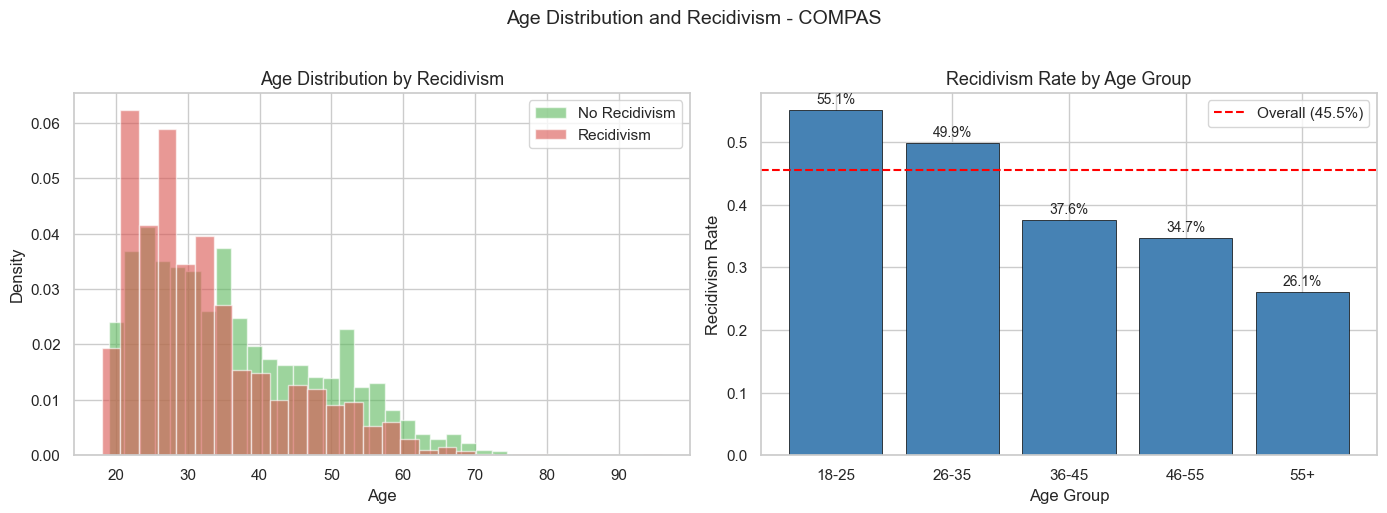

Youngest group (18-25) recidivism rate: 55.1%
Oldest group (55+) recidivism rate: 26.1%


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(df[df['label']==0]['age'], bins=30, alpha=0.6,
         color='#5cb85c', label='No Recidivism', density=True)
ax1.hist(df[df['label']==1]['age'], bins=30, alpha=0.6,
         color='#d9534f', label='Recidivism', density=True)
ax1.set_title('Age Distribution by Recidivism', fontsize=13)
ax1.set_xlabel('Age')
ax1.set_ylabel('Density')
ax1.legend()

age_bins = [18, 25, 35, 45, 55, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '55+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)
age_recid = df.groupby('age_group', observed=False)['label'].mean()
ax2.bar(age_recid.index, age_recid.values,
        color='steelblue', edgecolor='black', linewidth=0.5)
ax2.axhline(y=df['label'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Overall ({df["label"].mean():.1%})')
ax2.set_title('Recidivism Rate by Age Group', fontsize=13)
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Recidivism Rate')
ax2.legend()
for i, (grp, rate) in enumerate(age_recid.items()):
    ax2.text(i, rate + 0.01, f'{rate:.1%}', ha='center', fontsize=10)

plt.suptitle('Age Distribution and Recidivism - COMPAS', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/compas_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Youngest group (18-25) recidivism rate: {age_recid["18-25"]:.1%}')
print(f'Oldest group (55+) recidivism rate: {age_recid["55+"]:.1%}')

## 5. COMPAS Decile Score Distribution

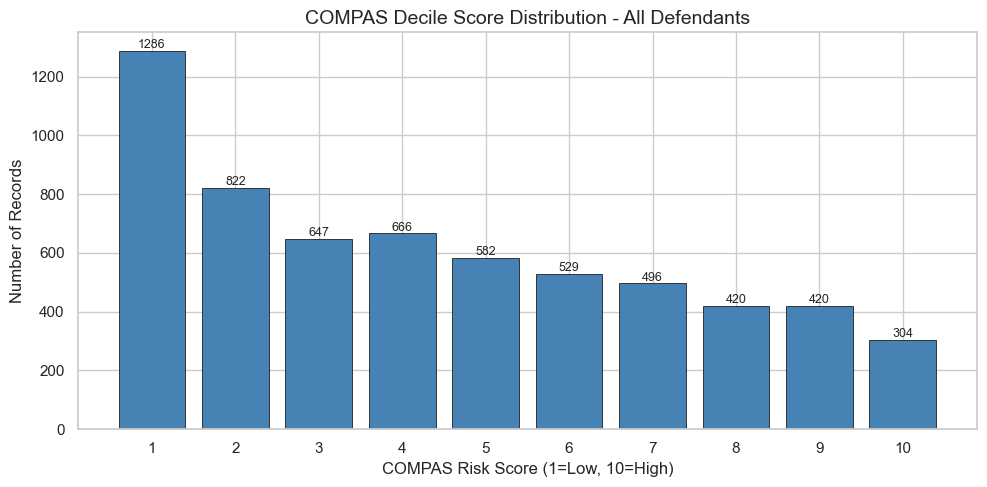

Mean score: 4.42 | Median: 4


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
score_counts = df['decile_score'].value_counts().sort_index()
ax.bar(score_counts.index, score_counts.values,
       color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_title('COMPAS Decile Score Distribution - All Defendants', fontsize=14)
ax.set_xlabel('COMPAS Risk Score (1=Low, 10=High)')
ax.set_ylabel('Number of Records')
ax.set_xticks(range(1, 11))
for i, (score, count) in enumerate(score_counts.items()):
    ax.text(score, count + 10, str(count), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/compas_decile_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean score: {df["decile_score"].mean():.2f} | Median: {df["decile_score"].median():.0f}')

## 6. COMPAS Decile Score by Race

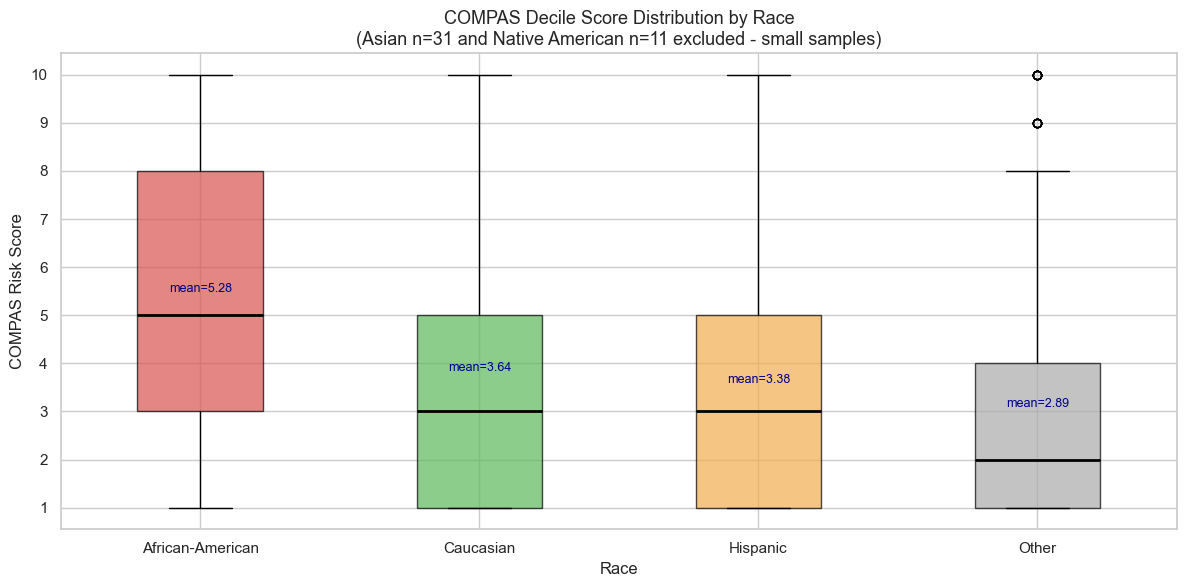

African-American mean score: 5.28
Caucasian mean score: 3.64
Score gap: 1.64


In [8]:
race_order = df.groupby('race')['decile_score'].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 6))
df_plot = df[df['race'].isin(['African-American', 'Caucasian', 'Hispanic', 'Other'])]
race_order_plot = ['African-American', 'Caucasian', 'Hispanic', 'Other']
data_to_plot = [df_plot[df_plot['race']==r]['decile_score'].values
                for r in race_order_plot]
bp = ax.boxplot(data_to_plot, labels=race_order_plot, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
colors = ['#d9534f', '#5cb85c', '#f0ad4e', '#aaaaaa']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('COMPAS Decile Score Distribution by Race\n(Asian n=31 and Native American n=11 excluded - small samples)', fontsize=13)
ax.set_xlabel('Race')
ax.set_ylabel('COMPAS Risk Score')
ax.set_yticks(range(1, 11))
for i, race in enumerate(race_order_plot):
    mean_score = df[df['race']==race]['decile_score'].mean()
    ax.text(i+1, mean_score + 0.2, f'mean={mean_score:.2f}',
            ha='center', fontsize=9, color='darkblue')
plt.tight_layout()
plt.savefig('../figures/eda/compas_decile_score_by_race.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'African-American mean score: {df[df["race"]=="African-American"]["decile_score"].mean():.2f}')
print(f'Caucasian mean score: {df[df["race"]=="Caucasian"]["decile_score"].mean():.2f}')
print(f'Score gap: {df[df["race"]=="African-American"]["decile_score"].mean() - df[df["race"]=="Caucasian"]["decile_score"].mean():.2f}')

## 7. Decile Score vs Actual Recidivism, Calibration

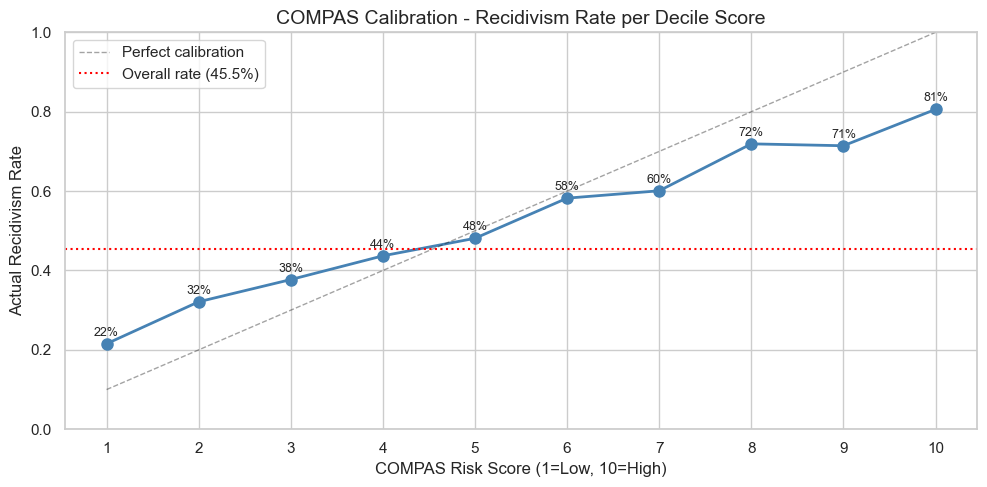

Score 1 recidivism rate: 21.5%
Score 10 recidivism rate: 80.6%


In [9]:
score_recid = df.groupby('decile_score')['label'].mean()
score_counts = df.groupby('decile_score')['label'].count()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(score_recid.index, score_recid.values, 'o-',
        color='steelblue', linewidth=2, markersize=8)
ax.plot([1, 10], [1/10, 10/10], 'k--', linewidth=1, alpha=0.4, label='Perfect calibration')
ax.axhline(y=df['label'].mean(), color='red', linestyle=':', linewidth=1.5,
           label=f'Overall rate ({df["label"].mean():.1%})')
ax.set_title('COMPAS Calibration - Recidivism Rate per Decile Score', fontsize=14)
ax.set_xlabel('COMPAS Risk Score (1=Low, 10=High)')
ax.set_ylabel('Actual Recidivism Rate')
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 1)
ax.legend()
for score, rate in score_recid.items():
    ax.text(score, rate + 0.02, f'{rate:.0%}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/compas_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Score 1 recidivism rate:', f'{score_recid[1]:.1%}')
print('Score 10 recidivism rate:', f'{score_recid[10]:.1%}')

## 8. False Positive and Negative Rates by Race

**The ProPublica finding:** Among defendants who did not reoffend, Black defendants were labeled medium or high risk at nearly twice the rate of white defendants (44.9% vs 23.5%, per Angwin et al. 2016, ProPublica). Among defendants who did reoffend, white defendants were labeled low risk about 1.7 times as often as Black defendants (roughly 48% vs 28%). Error-rate gaps like this are what the equalized odds constraint in Stage 2 targets. FAPE's own recomputation on this 6,172-record subset is presented separately in Section 14 below.

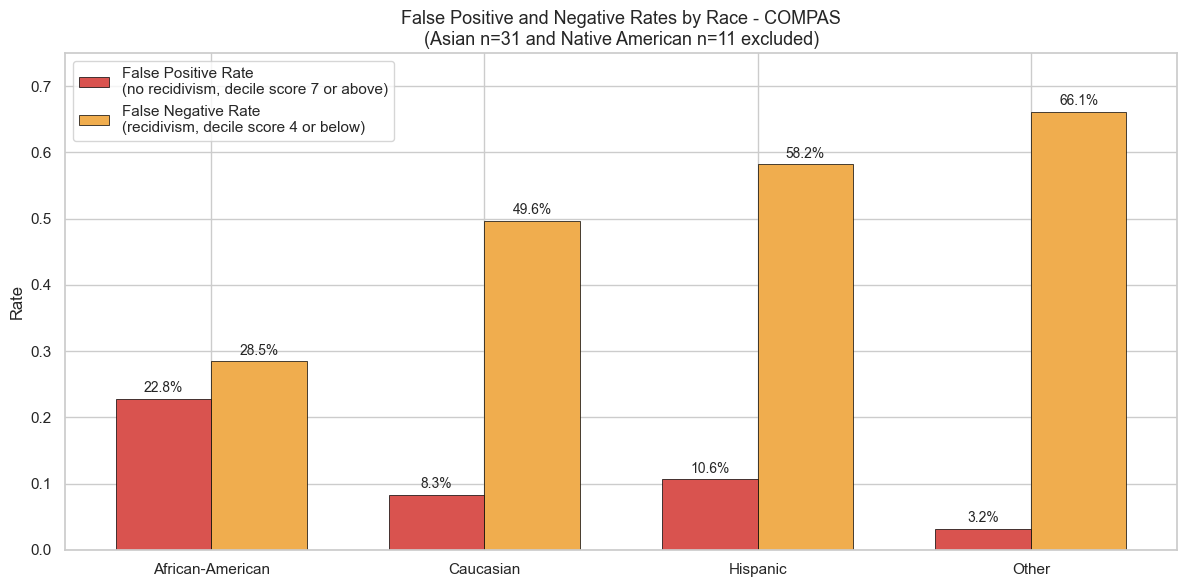

African-American FPR: 22.8% vs Caucasian FPR: 8.3%
FPR gap: 14.5%; African-American defendants who did not reoffend were scored 7 or above 2.8x as often as Caucasian defendants


In [10]:
races_to_plot = ['African-American', 'Caucasian', 'Hispanic', 'Other']
fpr_list = []
fnr_list = []
for race in races_to_plot:
    race_df = df[df['race'] == race]
    no_recid = race_df[race_df['label'] == 0]
    did_recid = race_df[race_df['label'] == 1]
    fpr = (no_recid['decile_score'] >= 7).mean()
    fnr = (did_recid['decile_score'] <= 4).mean()
    fpr_list.append(fpr)
    fnr_list.append(fnr)

x = range(len(races_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar([i - width/2 for i in x], fpr_list, width,
               label='False Positive Rate\n(no recidivism, decile score 7 or above)',
               color='#d9534f', edgecolor='black', linewidth=0.5)
bars2 = ax.bar([i + width/2 for i in x], fnr_list, width,
               label='False Negative Rate\n(recidivism, decile score 4 or below)',
               color='#f0ad4e', edgecolor='black', linewidth=0.5)
ax.set_title('False Positive and Negative Rates by Race - COMPAS\n(Asian n=31 and Native American n=11 excluded)', fontsize=13)
ax.set_xticks(list(x))
ax.set_xticklabels(races_to_plot)
ax.set_ylabel('Rate')
ax.set_ylim(0, 0.75)
ax.legend()
for bar, val in zip(bars1, fpr_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', fontsize=10)
for bar, val in zip(bars2, fnr_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/eda/compas_fpr_fnr_by_race.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'African-American FPR: {fpr_list[0]:.1%} vs Caucasian FPR: {fpr_list[1]:.1%}')
print(f'FPR gap: {abs(fpr_list[0]-fpr_list[1]):.1%}; African-American defendants who did not reoffend were '
      f'scored 7 or above {fpr_list[0]/fpr_list[1]:.1f}x as often as Caucasian defendants')

## 9. Prior Convictions by Race

Prior convictions correlate with the recidivism label at 0.291, more than any other feature except the COMPAS decile score (0.365). Prior convictions can also reflect historical policing patterns as well as behavior, a proxy problem similar to the one Obermeyer et al. (2019) documented in healthcare.

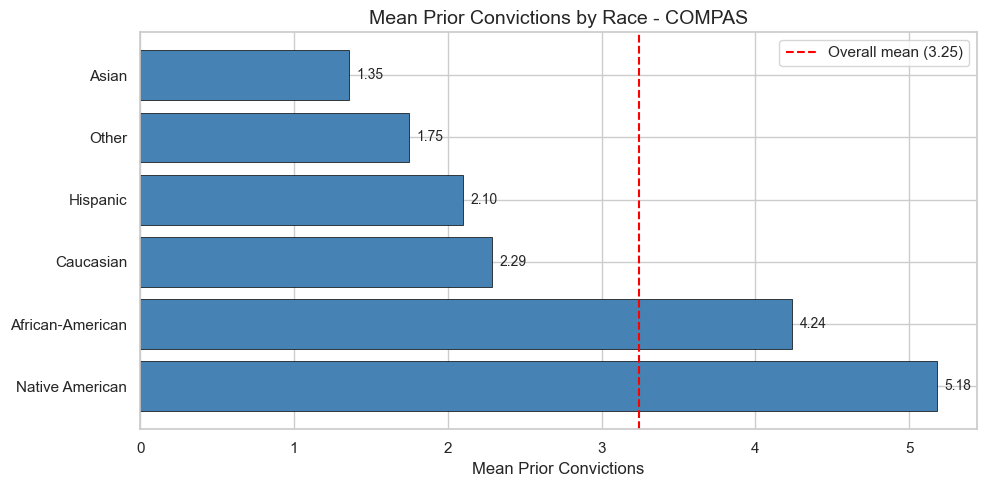

African-American mean priors: 4.24
Caucasian mean priors: 2.29
Prior conviction gap: 1.95, which can reflect policing patterns as well as behavior


In [11]:
race_priors = df.groupby('race')['priors_count'].agg(['mean','median','std']).reset_index()
race_priors = race_priors.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(race_priors['race'], race_priors['mean'],
               color='steelblue', edgecolor='black', linewidth=0.5)
ax.axvline(x=df['priors_count'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Overall mean ({df["priors_count"].mean():.2f})')
ax.set_title('Mean Prior Convictions by Race - COMPAS', fontsize=14)
ax.set_xlabel('Mean Prior Convictions')
ax.legend()
for bar, val in zip(bars, race_priors['mean']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/eda/compas_priors_by_race.png', dpi=150, bbox_inches='tight')
plt.show()
aa_priors = df[df['race']=='African-American']['priors_count'].mean()
ca_priors = df[df['race']=='Caucasian']['priors_count'].mean()
print(f'African-American mean priors: {aa_priors:.2f}')
print(f'Caucasian mean priors: {ca_priors:.2f}')
print(f'Prior conviction gap: {aa_priors - ca_priors:.2f}, which can reflect policing patterns as well as behavior')

## 10. Prior Convictions Distribution by Recidivism

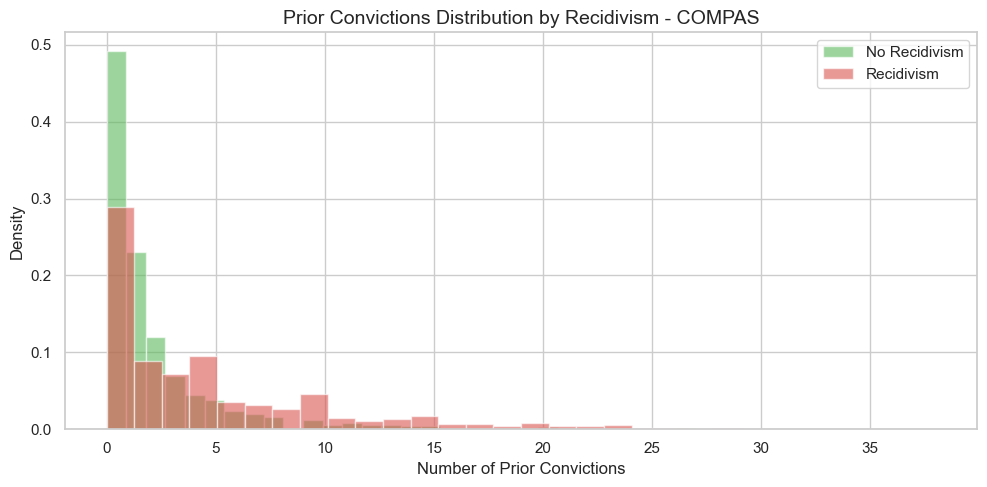

Priors-recidivism correlation: 0.291
Recidivism group mean priors: 4.75
No recidivism group mean priors: 1.99


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df[df['label']==0]['priors_count'], bins=30, alpha=0.6,
        color='#5cb85c', label='No Recidivism', density=True)
ax.hist(df[df['label']==1]['priors_count'], bins=30, alpha=0.6,
        color='#d9534f', label='Recidivism', density=True)
ax.set_title('Prior Convictions Distribution by Recidivism - COMPAS', fontsize=14)
ax.set_xlabel('Number of Prior Convictions')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/compas_priors_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
corr = df['priors_count'].corr(df['label'])
print(f'Priors-recidivism correlation: {corr:.3f}')
print(f'Recidivism group mean priors: {df[df["label"]==1]["priors_count"].mean():.2f}')
print(f'No recidivism group mean priors: {df[df["label"]==0]["priors_count"].mean():.2f}')

## 11. Charge Degree vs Recidivism

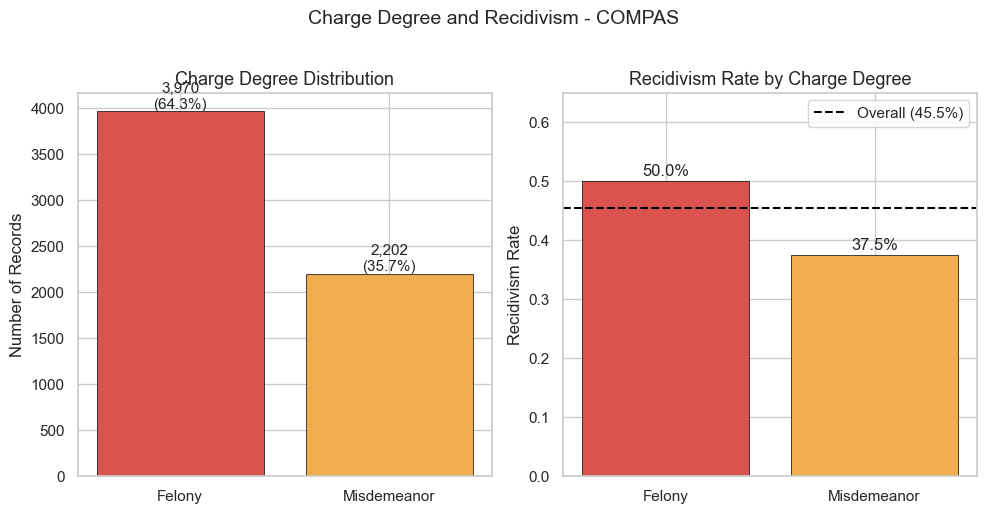

In [13]:
charge_stats = df.groupby('c_charge_degree').agg(
    count=('label', 'count'),
    recid_rate=('label', 'mean')
).reset_index()
charge_stats['label_name'] = charge_stats['c_charge_degree'].map(
    {'F': 'Felony', 'M': 'Misdemeanor'})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.bar(charge_stats['label_name'], charge_stats['count'],
        color=['#d9534f', '#f0ad4e'], edgecolor='black', linewidth=0.5)
ax1.set_title('Charge Degree Distribution', fontsize=13)
ax1.set_ylabel('Number of Records')
for i, (_, row) in enumerate(charge_stats.iterrows()):
    ax1.text(i, row['count'] + 30,
             f'{int(row["count"]):,}\n({row["count"]/len(df):.1%})',
             ha='center', fontsize=11)

ax2.bar(charge_stats['label_name'], charge_stats['recid_rate'],
        color=['#d9534f', '#f0ad4e'], edgecolor='black', linewidth=0.5)
ax2.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Overall ({df["label"].mean():.1%})')
ax2.set_title('Recidivism Rate by Charge Degree', fontsize=13)
ax2.set_ylabel('Recidivism Rate')
ax2.set_ylim(0, 0.65)
ax2.legend()
for i, (_, row) in enumerate(charge_stats.iterrows()):
    ax2.text(i, row['recid_rate'] + 0.01,
             f'{row["recid_rate"]:.1%}', ha='center', fontsize=12)

plt.suptitle('Charge Degree and Recidivism - COMPAS', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/compas_charge_degree.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Intersectional Analysis, Race × Sex

Note: Native American (n=11) and Asian (n=31) cells are unreliable due to small sample sizes. Sample sizes shown in parentheses for transparency.

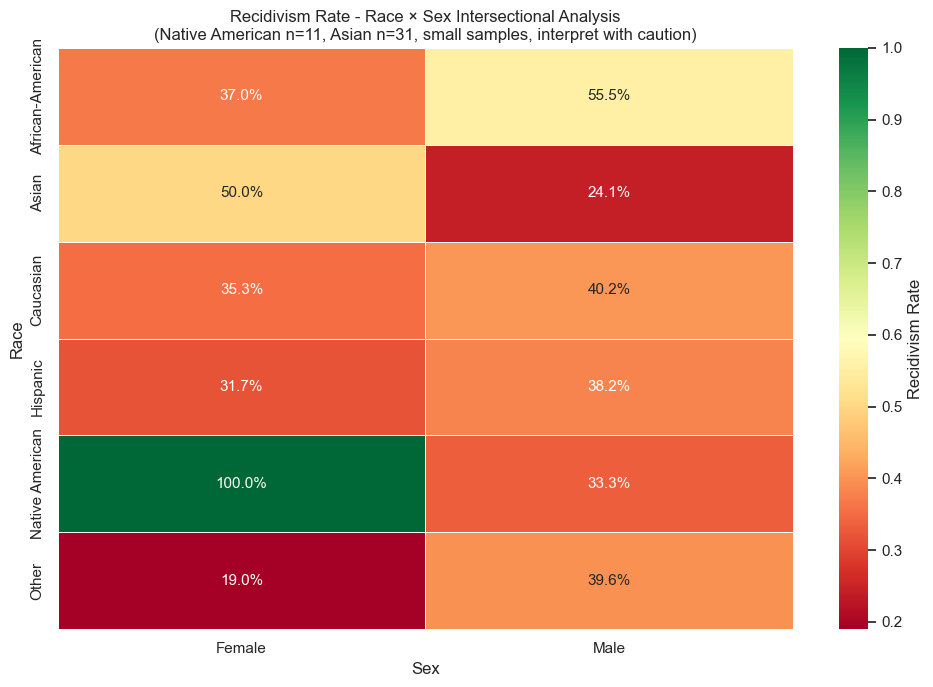

Sample sizes per cell:
sex               Female  Male
race                          
African-American     549  2626
Asian                  2    29
Caucasian            482  1621
Hispanic              82   427
Native American        2     9
Other                 58   285


In [14]:
pivot = df.groupby(['race', 'sex'])['label'].mean().unstack()
pivot_n = df.groupby(['race', 'sex'])['label'].count().unstack()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn',
            ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Recidivism Rate'})
ax.set_title('Recidivism Rate - Race × Sex Intersectional Analysis\n'
             '(Native American n=11, Asian n=31, small samples, interpret with caution)',
             fontsize=12)
ax.set_xlabel('Sex')
ax.set_ylabel('Race')
plt.tight_layout()
plt.savefig('../figures/eda/compas_intersectional.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample sizes per cell:')
print(pivot_n)

## 13. Feature Correlations with Recidivism Label

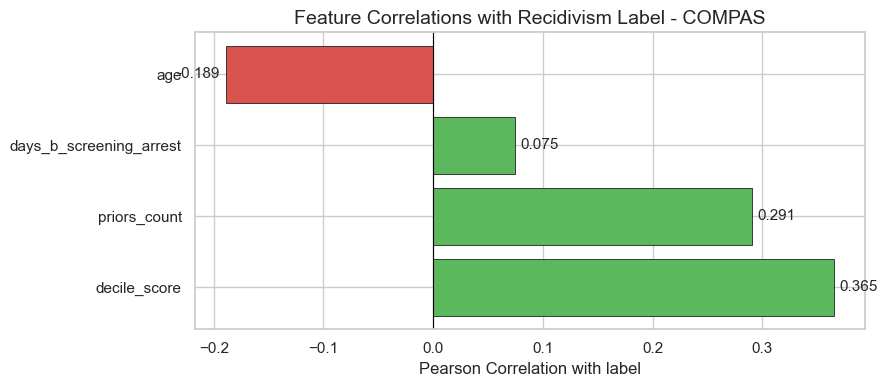

decile_score has the highest correlation with the label (0.365)
age correlation with the label: -0.189


In [15]:
numeric_cols = ['age', 'priors_count', 'decile_score', 'days_b_screening_arrest']
correlations = df[numeric_cols + ['label']].corr()['label'].drop('label').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#5cb85c' if v > 0 else '#d9534f' for v in correlations.values]
bars = ax.barh(correlations.index, correlations.values,
               color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Feature Correlations with Recidivism Label - COMPAS', fontsize=14)
ax.set_xlabel('Pearson Correlation with label')
for i, (feat, val) in enumerate(correlations.items()):
    offset = 0.005 if val >= 0 else -0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, i, f'{val:.3f}', va='center', ha=ha, fontsize=11)
plt.tight_layout()
plt.savefig('../figures/eda/compas_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'{correlations.idxmax()} has the highest correlation with the label ({correlations.max():.3f})')
print(f"age correlation with the label: {correlations['age']:.3f}")

## 14. Key Fairness Observations

**Recidivism gap:** African-American defendants reoffended at 52.3% vs 39.1% for Caucasian, a 13.2% raw gap. Raw gap does not imply algorithmic bias, base rate differences and historical data collection patterns require careful interpretation.

**Algorithmic score gap:** African-American mean COMPAS score 5.28 vs Caucasian 3.64, a 1.64 point raw gap; this comparison does not adjust for base rate differences.

**FAPE recomputation on this subset:** Among defendants who did not reoffend, 22.8% of African-American and 8.3% of Caucasian defendants had decile scores of 7 or above, a 14.5 percentage-point gap. ProPublica counted medium and high scores (5 and above) as higher risk, a lower cutoff, so its rates (44.9% vs 23.5%) are higher; the direction is the same. Among defendants who did reoffend, 49.6% of Caucasian and 28.5% of African-American defendants had scores of 4 or below, the same low-risk cutoff ProPublica used, and these rates are close to its roughly 48% and 28%.

**Proxy variable bias:** African-American defendants have 4.24 mean prior convictions vs 2.29 for Caucasian defendants. Prior convictions can reflect historical policing patterns as well as behavior, a proxy problem similar to the one Obermeyer et al. (2019) documented in healthcare.

**Small sample caveat:** Native American (n=11) and Asian (n=31) results should be interpreted with caution, sample sizes are insufficient for reliable statistical inference.

**FAPE Stage 2 will compute formal fairness metrics**, demographic parity difference, equalized odds difference, and disparate impact ratio, to quantify these patterns precisely across all domains.